In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))
from paths import *


# Prompt ablation


## Setup


In [ ]:
# eval and rich differed in two ways at once so the comparison couldn't determined which was of more importance. 
#   eval  bare token,                     no negative
#   rich  token + habitat + camera,       style negative
#
# eval_neg fills in the third cell of the 2x2: bare prompt with the style
# negative. 

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

PP    = str(ROOT)
BASE  = str(ROOT)
STAGE = "/content/staged_ablation"

%cd $PP
!nvidia-smi --query-gpu=name,memory.total --format=csv


Mounted at /content/drive
/content/drive/MyDrive/plant_pipeline
name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
!pip install -q "diffusers>=0.31" "transformers>=4.44" accelerate safetensors opencv-python


## Config


In [3]:
# 2x2: prompt (bare or descriptive) x negative (absent or present)
SPECIES = {
    "achillea":    {"token": "l35tgyhtew", "binomial": "Achillea maritima"},
    "eryngium":    {"token": "k92vbnqxdr", "binomial": "Eryngium maritimum"},
    "carpobrotus": {"token": "z47mfpwjhs", "binomial": "Carpobrotus acinaciformis"},
}

LORA     = BASE + "/outputs/sdxl_{species}/lora.safetensors"
OUT_ROOT = f"{PP}/generated_ablation"

BARE = "a detailed realistic photograph of {subject}"
RICH = ("a detailed realistic photograph of {subject} growing in sand dunes, "
        "natural daylight, sharp focus, fine leaf and petal detail, "
        "shot on a 100mm macro lens at f/8")

STYLE_NEG = ("drawing, sketch, line art, illustration, cartoon, painting, "
             "flat colour, oversaturated, neon, lowres, worst quality, "
             "watermark, text, person, hands, floating plant, cut out, "
             "heavy bokeh, soft focus")

CONDITIONS = {
    "eval":       {"prompt": BARE, "negative": ""},          # already run
    "rich":       {"prompt": RICH, "negative": STYLE_NEG},   # already run
    "eval_neg":   {"prompt": BARE, "negative": STYLE_NEG},   # the new one
    "rich_noneg": {"prompt": RICH, "negative": ""},          # completes the 2x2
}

# generation parameters, held constant across every condition
SCALE      = 0.75
MULTIPLIER = 0.8
STRENGTH   = 0.85
SEED       = 1234

import glob
for s in SPECIES:
    p = LORA.format(species=s)
    n = len([f for f in glob.glob(f"out/{s}/*.png")
             if not f.endswith(("_flat.png", "_mask.png", "_control.png"))])
    print(f"{s:<14} lora {'ok ' if os.path.exists(p) else 'MISSING':<8} specs {n}")


achillea       lora ok       specs 200
eryngium       lora ok       specs 200
carpobrotus    lora ok       specs 188


## Stage the specifications


In [4]:
# copies into staged_ablation/<condition>/<species>/ and writes sidecars
# there, so nothing goes on the command line and build_species.py's own
# sidecars stay untouched
import shutil
from pathlib import Path

def specs_for(species):
    return sorted(f for f in glob.glob(f"{PP}/out/{species}/*.png")
                  if not f.endswith(("_flat.png", "_mask.png", "_control.png")))

def stage(condition, species, n_per_species=None):
    cfg = CONDITIONS[condition]
    prompt = cfg["prompt"].format(subject=SPECIES[species]["token"])
    negative = cfg["negative"]

    d = Path(STAGE) / condition / species
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True)

    picked = specs_for(species)
    if n_per_species:
        picked = picked[:n_per_species]

    for src in picked:
        stem = Path(src).stem
        shutil.copy(src, d / f"{stem}.png")
        flat = Path(src).with_name(f"{stem}_flat.png")
        if flat.exists():
            shutil.copy(flat, d / f"{stem}_flat.png")
        (d / f"{stem}.txt").write_text(prompt)
        (d / f"{stem}.neg.txt").write_text(negative)

    return d, len(picked), prompt, negative

d, n, p, neg = stage("eval_neg", "achillea", n_per_species=1)
print(f"staged {n} -> {d}")
print("prompt  :", p)
print("negative:", (neg[:70] + "...") if neg else "(none)")


staged 1 -> /content/staged_ablation/eval_neg/achillea
prompt  : a detailed realistic photograph of l35tgyhtew
negative: drawing, sketch, line art, illustration, cartoon, painting, flat colou...


## Run


In [5]:
# achillea first, that's where the eval/rich gap was clearest.
# only eval_neg and rich_noneg need generating if the other two are already
# done. REDO_ALL regenerates all four here, safer if a parameter changed.
ABLATION_SPECIES = "achillea"
N_SPECS          = 1
REDO_ALL         = True     # False to run only the two new conditions

todo = list(CONDITIONS) if REDO_ALL else ["eval_neg", "rich_noneg"]
lora = LORA.format(species=ABLATION_SPECIES)

%cd $PP
for cond in todo:
    d, n, prompt, neg = stage(cond, ABLATION_SPECIES, n_per_species=N_SPECS)
    print(f"\n{'=' * 62}")
    print(f"{cond}   negative: {'yes' if neg else 'no'}")
    print(f"{prompt[:80]}")
    print("=" * 62)
    !python gen_flat_lora.py "{d}" \
        --lora "{lora}" --lora-multiplier {MULTIPLIER} \
        --strength {STRENGTH} --scale {SCALE} \
        --suffix _{cond} -n 1 --seed {SEED} \
        --out {OUT_ROOT}/{cond}/{ABLATION_SPECIES}


/content/drive/MyDrive/plant_pipeline

eval   negative: no
a detailed realistic photograph of l35tgyhtew
1 spec(s), 1 image(s) each
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100% 1.24k/1.24k [00:00<00:00, 4.50MB/s]

diffusion_pytorch_model.safetensors: downloading bytes:   0% 0.00/2.50G [00:00<?, ?B/s]
diffusion_pytorch_model.safetensors: downloading bytes:  12% 308M/2.50G [00:01<00:04, 466MB/s, 22.3MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file:   8% 201M/2.50G [00:01<00:13, 167MB/s, 5.56kB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes:  39% 977M/2.50G [00:02<00:01, 792MB/s, 77.2MB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes:  48% 1.19G/2.50G [00:02<00:01, 757MB/s, 99.4MB/s  ]
diffusion_pytorch_model.safetens

## The 2x2


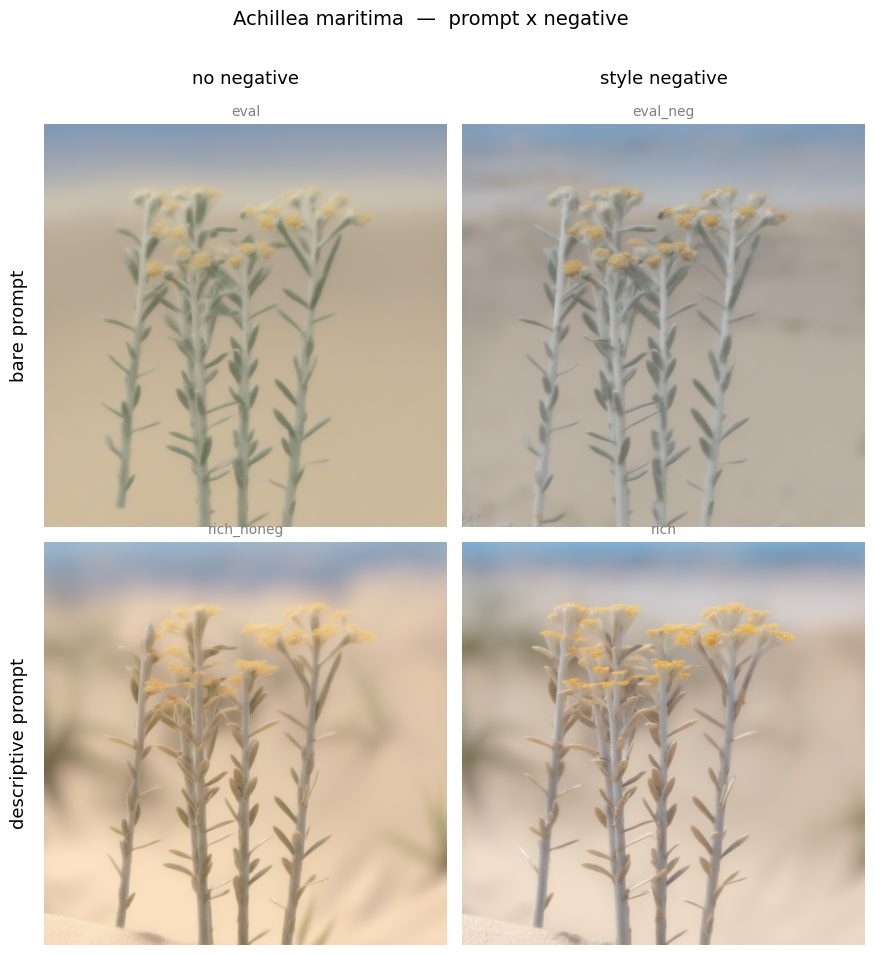

In [6]:
# rows prompt, columns negative. compare down the left column for the
# negative's effect with the prompt held constant.
import matplotlib.pyplot as plt
from PIL import Image as PILImage

GRID = [["eval", "eval_neg"],          # bare prompt
        ["rich_noneg", "rich"]]        # descriptive prompt
ROW_LABELS = ["bare prompt", "descriptive prompt"]
COL_LABELS = ["no negative", "style negative"]

fig, axes = plt.subplots(2, 2, figsize=(9, 9.6))

for i, row in enumerate(GRID):
    for j, cond in enumerate(row):
        ax = axes[i, j]
        ax.axis("off")
        hits = [h for h in sorted(
            glob.glob(f"{OUT_ROOT}/{cond}/{ABLATION_SPECIES}/*.png"))
            if not h.endswith("_control.png")]
        if hits:
            ax.imshow(PILImage.open(hits[0]))
        else:
            ax.text(.5, .5, f"{cond}\nnot generated", ha="center",
                    va="center", fontsize=10, color="grey")
        ax.set_title(cond, fontsize=10, color="grey")
        if i == 0:
            ax.text(.5, 1.10, COL_LABELS[j], transform=ax.transAxes,
                    ha="center", fontsize=13)
        if j == 0:
            ax.text(-.04, .5, ROW_LABELS[i], transform=ax.transAxes,
                    rotation=90, va="center", ha="right", fontsize=13)

plt.suptitle(f"{SPECIES[ABLATION_SPECIES]['binomial']}  -  prompt x negative",
             fontsize=14, y=0.99)
plt.tight_layout(rect=[0.02, 0, 1, 0.96])
plt.savefig(f"{PP}/ablation_{ABLATION_SPECIES}.png", dpi=120,
            bbox_inches="tight")
plt.show()


## negative terms


In [ ]:
# each variant drops one group of terms, so a cell that reverts to the washed-out look observed. five more
# generations, so only worth running  if the 2x2 points at the negative.
NEG_PARTS = {
    "full":        STYLE_NEG,
    "no_medium":   ("flat colour, oversaturated, neon, lowres, worst quality, "
                    "watermark, text, person, hands, floating plant, cut out, "
                    "heavy bokeh, soft focus"),
    "no_quality":  ("drawing, sketch, line art, illustration, cartoon, painting, "
                    "flat colour, oversaturated, neon, watermark, text, person, "
                    "hands, floating plant, cut out, heavy bokeh, soft focus"),
    "no_focus":    ("drawing, sketch, line art, illustration, cartoon, painting, "
                    "flat colour, oversaturated, neon, lowres, worst quality, "
                    "watermark, text, person, hands, floating plant, cut out"),
    "focus_only":  "heavy bokeh, soft focus, blurry",
    "medium_only": ("drawing, sketch, line art, illustration, cartoon, "
                    "painting, flat colour"),
}

RUN_NEG_SWEEP = False        # set True to run

if RUN_NEG_SWEEP:
    src_specs = specs_for(ABLATION_SPECIES)[:1]
    for name, neg in NEG_PARTS.items():
        d = Path(STAGE) / f"neg_{name}" / ABLATION_SPECIES
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True)
        prompt = BARE.format(subject=SPECIES[ABLATION_SPECIES]["token"])
        for src in src_specs:
            stem = Path(src).stem
            shutil.copy(src, d / f"{stem}.png")
            fl = Path(src).with_name(f"{stem}_flat.png")
            if fl.exists():
                shutil.copy(fl, d / f"{stem}_flat.png")
            (d / f"{stem}.txt").write_text(prompt)
            (d / f"{stem}.neg.txt").write_text(neg)
        print(f"\n--- neg_{name}")
        !python gen_flat_lora.py "{d}" \
            --lora "{lora}" --lora-multiplier {MULTIPLIER} \
            --strength {STRENGTH} --scale {SCALE} \
            --suffix _neg_{name} -n 1 --seed {SEED} \
            --out {OUT_ROOT}/neg_{name}/{ABLATION_SPECIES}
else:
    print("RUN_NEG_SWEEP is False")


RUN_NEG_SWEEP is False


In [8]:
if RUN_NEG_SWEEP:
    names = list(NEG_PARTS)
    fig, axes = plt.subplots(2, 3, figsize=(13, 9))
    for ax, name in zip(axes.ravel(), names):
        ax.axis("off")
        hits = [h for h in sorted(
            glob.glob(f"{OUT_ROOT}/neg_{name}/{ABLATION_SPECIES}/*.png"))
            if not h.endswith("_control.png")]
        if hits:
            ax.imshow(PILImage.open(hits[0]))
        ax.set_title(name, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{PP}/negative_sweep_{ABLATION_SPECIES}.png", dpi=120,
                bbox_inches="tight")
    plt.show()


## Other species


In [ ]:
# a prompt that suits achillea may not suit carpobrotus, so check the grid
# per species.
CHOSEN     = "eval_neg"      # set after reading the 2x2
N_PER_SPEC = 1

%cd $PP
for sp in SPECIES:
    d, n, prompt, neg = stage(CHOSEN, sp)
    if n == 0:
        print(f"{sp}: no specs")
        continue
    print(f"\n{'=' * 62}\n{sp}: {n} specs\n{prompt[:80]}\n{'=' * 62}")
    !python gen_flat_lora.py "{d}" \
        --lora "{LORA.format(species=sp)}" --lora-multiplier {MULTIPLIER} \
        --strength {STRENGTH} --scale {SCALE} \
        --suffix _{CHOSEN} -n {N_PER_SPEC} --seed {SEED} \
        --out {OUT_ROOT}/{CHOSEN}/{sp}


/content/drive/MyDrive/plant_pipeline

achillea: 200 specs
a detailed realistic photograph of l35tgyhtew
100 spec(s), 1 image(s) each
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:  14% 1/7 [00:01<00:07,  1.29s/it]
Loading weights: 100% 196/196 [00:00<00:00, 2763.84it/s]
Loading pipeline components...:  71% 5/7 [00:01<00:00,  3.79it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  43% 223/517 [00:00<00:00, 2229.64it/s]
Loading weights: 100% 517/517 [00:00<00:00, 2190.30it

## Record


In [10]:
import json, hashlib

record = {"parameters": {"scale": SCALE, "lora_multiplier": MULTIPLIER,
                         "strength": STRENGTH, "seed": SEED},
          "conditions": {}, "images": []}

for cond, cfg in CONDITIONS.items():
    d = f"{OUT_ROOT}/{cond}"
    if not os.path.exists(d):
        continue
    record["conditions"][cond] = {"prompt_template": cfg["prompt"],
                                  "negative": cfg["negative"]}
    for sp in sorted(os.listdir(d)):
        subject = SPECIES[sp]["token"]
        for f in sorted(glob.glob(f"{d}/{sp}/*.png")):
            if f.endswith("_control.png"):
                continue
            record["images"].append({
                "condition": cond, "species": sp, "path": f,
                "prompt": cfg["prompt"].format(subject=subject),
                "negative": cfg["negative"],
                "md5": hashlib.md5(open(f, "rb").read()).hexdigest(),
            })

os.makedirs(OUT_ROOT, exist_ok=True)
with open(f"{OUT_ROOT}/ablation_record.json", "w") as fh:
    json.dump(record, fh, indent=2)
print(f"{len(record['images'])} images, {len(record['conditions'])} conditions")
print(f"-> {OUT_ROOT}/ablation_record.json")


6 images, 4 conditions
-> /content/drive/MyDrive/plant_pipeline/generated_ablation/ablation_record.json
